# Data bn tanishuv 

In [103]:
import pandas as pd 
df=pd.read_csv('shoes_sales_dataset.csv')

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   str    
 1   Date           1000 non-null   str    
 2   Brand          1000 non-null   str    
 3   Shoe_Type      1000 non-null   str    
 4   Color          1000 non-null   str    
 5   Country        1000 non-null   str    
 6   Sales_Channel  1000 non-null   str    
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 78.2 KB


In [105]:
df.isnull().sum()

Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64

In [106]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

class Datapreprocessing:
    def __init__(self, df):
        self.df = df.copy()
    
    # Handle missing values
    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'str':
                    self.df[col].fillna(self.df[col].mode()[0], inplace=True)
                else:
                    self.df[col].fillna(self.df[col].mean(), inplace=True)
        return self
    
    # Encode categorical variables
    def encodla(self):
        encoder = LabelEncoder()
        for col in self.df.columns:
            if self.df[col].dtype == 'str':
                if self.df[col].nunique() <= 5:  # few categories → OneHot
                    dummies = pd.get_dummies(self.df[col], prefix=col, dtype=int)
                    self.df = pd.concat([self.df.drop(columns=[col]), dummies], axis=1)
                else:  # many categories → Label Encoding
                    self.df[col] = encoder.fit_transform(self.df[col])
        return self
    
    # Scale numeric features
    def scale_qil(self):
        scaler = MinMaxScaler()
        num_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.drop('xG', errors='ignore')
        self.df[num_cols] = scaler.fit_transform(self.df[num_cols])
        return self
    
    # Log transformation for skewed features
    def log_transform(self, threshold=0.5):
        skewness = self.df.skew()
        features_log = skewness[(skewness >= threshold)].index.tolist()
        
        for col in features_log:
            if (self.df[col] > 0).all():  # only positive values
                self.df[col] = np.log1p(self.df[col])
        return self


In [107]:
processor = Datapreprocessing(df)

df_ready = (
    processor
    .tozala()
    .encodla()
    .scale_qil()
    .log_transform()
    .df
)

print(df_ready.head())

    Sale_ID      Date  Brand  Shoe_Type  Color   Country  Price_USD  \
0  0.000000  0.891496    0.4        0.0    0.2  0.833333   0.371734   
1  0.112112  0.187683    1.0        0.0    0.6  1.000000   0.950758   
2  0.223223  0.589443    0.4        0.6    1.0  0.833333   0.730952   
3  0.334334  0.838710    0.2        0.2    0.4  0.666667   0.596930   
4  0.445445  0.759531    0.0        0.4    0.6  0.000000   0.152110   

   Units_Sold  Revenue_USD  Sales_Channel_Mall  Sales_Channel_Online  \
0    0.157895     0.085042                 0.0                   1.0   
1    0.157895     0.188393                 1.0                   0.0   
2    0.052632     0.071280                 1.0                   0.0   
3    0.000000     0.026359                 1.0                   0.0   
4    0.684211     0.176946                 0.0                   1.0   

   Sales_Channel_Retail Store  
0                         0.0  
1                         0.0  
2                         0.0  
3           

In [108]:
df=df_ready
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sale_ID                     1000 non-null   float64
 1   Date                        1000 non-null   float64
 2   Brand                       1000 non-null   float64
 3   Shoe_Type                   1000 non-null   float64
 4   Color                       1000 non-null   float64
 5   Country                     1000 non-null   float64
 6   Price_USD                   1000 non-null   float64
 7   Units_Sold                  1000 non-null   float64
 8   Revenue_USD                 1000 non-null   float64
 9   Sales_Channel_Mall          1000 non-null   float64
 10  Sales_Channel_Online        1000 non-null   float64
 11  Sales_Channel_Retail Store  1000 non-null   float64
dtypes: float64(12)
memory usage: 93.9 KB


# Filter Methot

# Correlation

In [109]:
import numpy as np

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
df_filtered = df.drop(columns=to_drop)
print("\nOriginal shape:", df.shape)
print("Shape after dropping correlated features:", df_filtered.shape)



Original shape: (1000, 12)
Shape after dropping correlated features: (1000, 12)


In [110]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sale_ID                     1000 non-null   float64
 1   Date                        1000 non-null   float64
 2   Brand                       1000 non-null   float64
 3   Shoe_Type                   1000 non-null   float64
 4   Color                       1000 non-null   float64
 5   Country                     1000 non-null   float64
 6   Price_USD                   1000 non-null   float64
 7   Units_Sold                  1000 non-null   float64
 8   Revenue_USD                 1000 non-null   float64
 9   Sales_Channel_Mall          1000 non-null   float64
 10  Sales_Channel_Online        1000 non-null   float64
 11  Sales_Channel_Retail Store  1000 non-null   float64
dtypes: float64(12)
memory usage: 93.9 KB


# More analysis

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

In [112]:
corr_matrix = df.corr().abs()
print(corr_matrix)

                             Sale_ID      Date     Brand  Shoe_Type     Color  \
Sale_ID                     1.000000  0.020953  0.005090   0.026716  0.014367   
Date                        0.020953  1.000000  0.029433   0.022473  0.056122   
Brand                       0.005090  0.029433  1.000000   0.030819  0.004101   
Shoe_Type                   0.026716  0.022473  0.030819   1.000000  0.008817   
Color                       0.014367  0.056122  0.004101   0.008817  1.000000   
Country                     0.025978  0.054876  0.023129   0.034239  0.023704   
Price_USD                   0.032987  0.036401  0.014234   0.034921  0.013944   
Units_Sold                  0.002591  0.026585  0.069833   0.006143  0.028077   
Revenue_USD                 0.023284  0.036329  0.060170   0.003710  0.011608   
Sales_Channel_Mall          0.002726  0.036300  0.037229   0.016100  0.000282   
Sales_Channel_Online        0.030406  0.005259  0.034054   0.024671  0.040084   
Sales_Channel_Retail Store  

In [113]:
high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] > 0.5:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])

corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print("Highly correlated feature pairs (correlation > 0.5):")
print(corr_table)

Highly correlated feature pairs (correlation > 0.5):
              Feature 1                   Feature 2  Correlation
0             Price_USD                 Revenue_USD         0.59
1            Units_Sold                 Revenue_USD         0.73
2    Sales_Channel_Mall  Sales_Channel_Retail Store         0.50
3  Sales_Channel_Online  Sales_Channel_Retail Store         0.50


In [114]:
df_filtered = df.drop(columns=to_drop)
print("\nOriginal shape:", df.shape)
print("Shape after dropping correlated features:", df_filtered.shape)


Original shape: (1000, 12)
Shape after dropping correlated features: (1000, 12)


# Vizual 

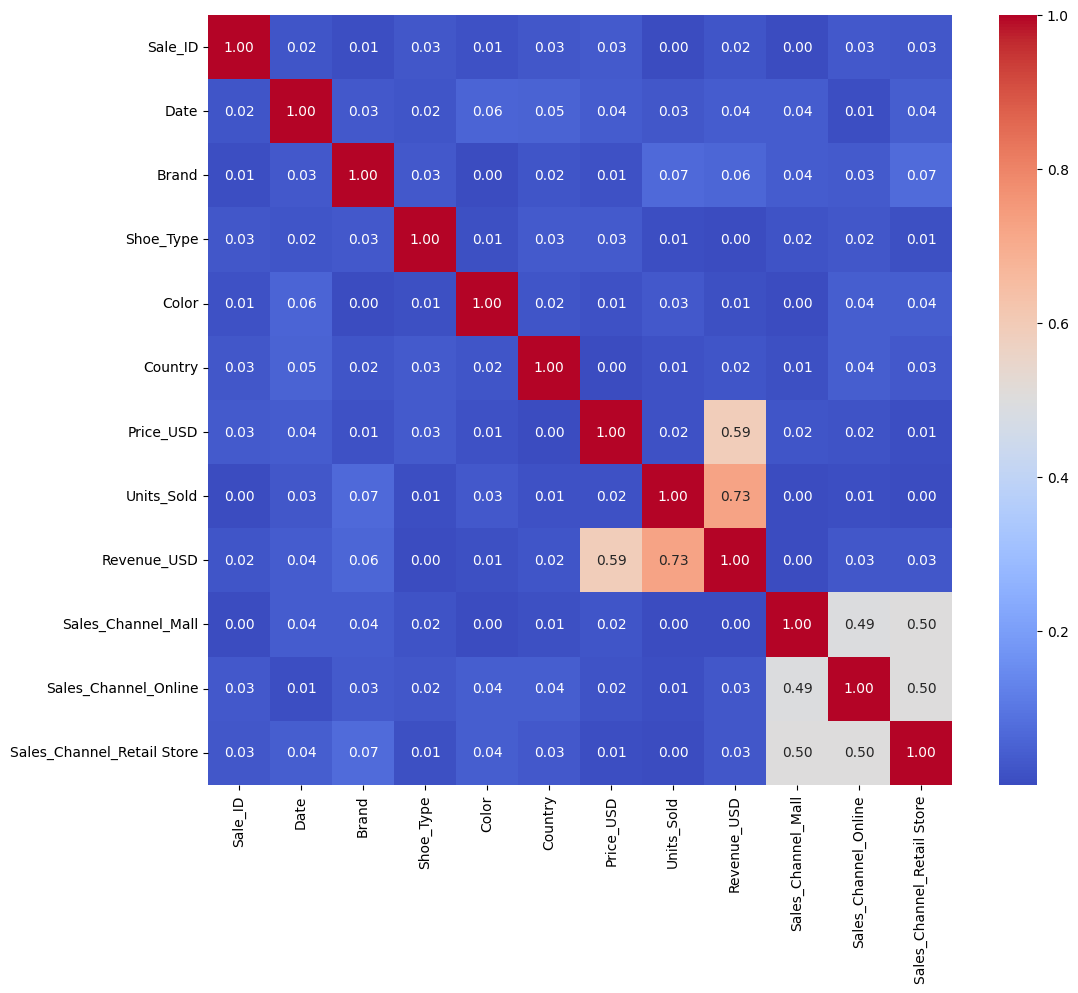

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Endi grafikni chizishingiz mumkin
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.show()

# Create a long-form dataframe for Plotly

In [116]:
import plotly.express as px
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Feature 1', 'Feature 2', 'Correlation']

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',       
    aspect="auto",
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1,
)

fig.update_layout(
    width=900,
    height=800,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()


# Low Vairance

In [117]:
from sklearn.feature_selection import VarianceThreshold
threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
selector.fit(df_filtered)

low_variance_features = df_filtered.columns[~selector.get_support()]
print("Features with low variance (to drop):", list(low_variance_features))
df_low_variance_filtered = df_filtered.drop(columns=low_variance_features)
print("\nOriginal shape:", df_filtered.shape)
print("Shape after dropping low-variance features:", df_low_variance_filtered.shape)

Features with low variance (to drop): []

Original shape: (1000, 12)
Shape after dropping low-variance features: (1000, 12)


In [118]:
low_variance_features = df_filtered.columns[~selector.get_support()]
print("Features with low variance (to drop):", list(low_variance_features))

Features with low variance (to drop): []


# Ploty express

In [119]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
variances = df[numeric_cols].var()

threshold = 0.05
low_variance_features = variances[variances < threshold].index.tolist()

var_df = pd.DataFrame({
    'Feature': variances.index,
    'Variance': variances.values,
    'LowVariance': ['Yes' if f in low_variance_features else 'No' for f in variances.index]
})


fig = px.bar(
    var_df,
    x='Feature',
    y='Variance',
    color='LowVariance',
    color_discrete_map={'Yes': 'red', 'No': 'blue'},
    text='Variance',
    title='()'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()

In [120]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sale_ID                     1000 non-null   float64
 1   Date                        1000 non-null   float64
 2   Brand                       1000 non-null   float64
 3   Shoe_Type                   1000 non-null   float64
 4   Color                       1000 non-null   float64
 5   Country                     1000 non-null   float64
 6   Price_USD                   1000 non-null   float64
 7   Units_Sold                  1000 non-null   float64
 8   Revenue_USD                 1000 non-null   float64
 9   Sales_Channel_Mall          1000 non-null   float64
 10  Sales_Channel_Online        1000 non-null   float64
 11  Sales_Channel_Retail Store  1000 non-null   float64
dtypes: float64(12)
memory usage: 93.9 KB


In [121]:
# Recursev Feature Elimination
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = df.drop('Revenue_USD', axis=1)
y = df['Revenue_USD']

In [122]:
model = LinearRegression()
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected features:", selected_features)

Selected features: Index(['Sale_ID', 'Date', 'Shoe_Type', 'Color', 'Country', 'Price_USD',
       'Units_Sold', 'Sales_Channel_Mall', 'Sales_Channel_Online',
       'Sales_Channel_Retail Store'],
      dtype='str')


# Embedded Methods 

In [123]:
from sklearn.linear_model import LassoCV
X = df.drop('Revenue_USD', axis=1)
y = df['Revenue_USD']
lasso = LassoCV(cv=10, random_state=42).fit(X, y)
importance = np.abs(lasso.coef_)

In [124]:
percentile_threshold = np.percentile(importance, 75)  # top 25% features
top_features = X.columns[importance >= percentile_threshold]

print("\nTop 25% important features based on Lasso coefficients:")
print(top_features.tolist())


Top 25% important features based on Lasso coefficients:
['Shoe_Type', 'Price_USD', 'Units_Sold']


# Table

In [125]:
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Mark top 25% most important features
percentile_threshold = np.percentile(importance, 65)
feat_df['Top25%'] = np.where(feat_df['Importance'] >= percentile_threshold, 'Yes', 'No')

# Show table
print("Feature Importance Table:")
print(feat_df)

Feature Importance Table:
                       Feature  Importance Top25%
7                   Units_Sold    0.537252    Yes
6                    Price_USD    0.461049    Yes
3                    Shoe_Type    0.011153    Yes
10  Sales_Channel_Retail Store    0.011076    Yes
5                      Country    0.004377     No
0                      Sale_ID    0.000000     No
1                         Date    0.000000     No
2                        Brand    0.000000     No
4                        Color    0.000000     No
8           Sales_Channel_Mall    0.000000     No
9         Sales_Channel_Online    0.000000     No


In [126]:
fig = px.bar(
    feat_df,
    x='Feature',
    y='Importance',
    color='Top25%',
    color_discrete_map={'Yes': 'red', 'No': 'blue'},
    text='Importance',
    title='Lasso Feature Importance'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=600
)


# Tree based(Random Forest)

In [127]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

percentile_threshold = np.percentile(importances, 75)
feat_df['Top25%'] = np.where(feat_df['Importance'] >= percentile_threshold, 'Yes', 'No')

print("Random Forest Feature Importance Table:")
print(feat_df)

Random Forest Feature Importance Table:
                       Feature  Importance Top25%
7                   Units_Sold    0.533870    Yes
6                    Price_USD    0.462890    Yes
0                      Sale_ID    0.000699    Yes
1                         Date    0.000690     No
2                        Brand    0.000397     No
3                    Shoe_Type    0.000390     No
5                      Country    0.000387     No
4                        Color    0.000376     No
9         Sales_Channel_Online    0.000114     No
8           Sales_Channel_Mall    0.000094     No
10  Sales_Channel_Retail Store    0.000093     No


In [128]:
fig = px.bar(
    feat_df,
    x='Feature',
    y='Importance',
    color='Top25%',
    color_discrete_map={'Yes': 'red', 'No': 'blue'},
    text='Importance',
    title='Random Forest Feature Importance'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sale_ID                     1000 non-null   float64
 1   Date                        1000 non-null   float64
 2   Brand                       1000 non-null   float64
 3   Shoe_Type                   1000 non-null   float64
 4   Color                       1000 non-null   float64
 5   Country                     1000 non-null   float64
 6   Price_USD                   1000 non-null   float64
 7   Units_Sold                  1000 non-null   float64
 8   Revenue_USD                 1000 non-null   float64
 9   Sales_Channel_Mall          1000 non-null   float64
 10  Sales_Channel_Online        1000 non-null   float64
 11  Sales_Channel_Retail Store  1000 non-null   float64
dtypes: float64(12)
memory usage: 93.9 KB


In [130]:
numeric_cols = df.select_dtypes(include=['number']).columns

skewness = df[numeric_cols].skew()

log_transformation = skewness[skewness >= 0.5].index.tolist()

print(log_transformation)

['Revenue_USD', 'Sales_Channel_Mall', 'Sales_Channel_Online', 'Sales_Channel_Retail Store']


In [131]:
log_transformation

['Revenue_USD',
 'Sales_Channel_Mall',
 'Sales_Channel_Online',
 'Sales_Channel_Retail Store']

In [132]:
for col in log_transformation:
    df[col+'_log']=np.log1p(df[col])

In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sale_ID                         1000 non-null   float64
 1   Date                            1000 non-null   float64
 2   Brand                           1000 non-null   float64
 3   Shoe_Type                       1000 non-null   float64
 4   Color                           1000 non-null   float64
 5   Country                         1000 non-null   float64
 6   Price_USD                       1000 non-null   float64
 7   Units_Sold                      1000 non-null   float64
 8   Revenue_USD                     1000 non-null   float64
 9   Sales_Channel_Mall              1000 non-null   float64
 10  Sales_Channel_Online            1000 non-null   float64
 11  Sales_Channel_Retail Store      1000 non-null   float64
 12  Revenue_USD_log                 1000 non-null 

In [134]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Price_USD', 'Units_Sold', 'Revenue_USD', 'Sales_Channel_Mall',
       'Sales_Channel_Online', 'Sales_Channel_Retail Store', 'Revenue_USD_log',
       'Sales_Channel_Mall_log', 'Sales_Channel_Online_log',
       'Sales_Channel_Retail Store_log'],
      dtype='str')>

In [135]:
numeric_df = df.select_dtypes(include=['number'])

skewness = numeric_df.skew()
print(skewness.sort_values(ascending=False))

Revenue_USD                       8.540459e-01
Sales_Channel_Mall_log            7.241637e-01
Sales_Channel_Mall                7.241637e-01
Sales_Channel_Online              7.193526e-01
Sales_Channel_Online_log          7.193526e-01
Sales_Channel_Retail Store        6.812515e-01
Sales_Channel_Retail Store_log    6.812515e-01
Revenue_USD_log                   5.937149e-01
Date                              4.865480e-02
Price_USD                         3.884252e-02
Color                             3.853667e-02
Shoe_Type                         2.023019e-02
Sale_ID                          -7.373122e-17
Country                          -3.296434e-03
Units_Sold                       -4.109728e-03
Brand                            -6.580341e-02
dtype: float64


In [136]:
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['str']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# Train

In [137]:
X = df.drop('Revenue_USD', axis=1)
y = df['Revenue_USD']

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sale_ID                         1000 non-null   float64
 1   Date                            1000 non-null   float64
 2   Brand                           1000 non-null   float64
 3   Shoe_Type                       1000 non-null   float64
 4   Color                           1000 non-null   float64
 5   Country                         1000 non-null   float64
 6   Price_USD                       1000 non-null   float64
 7   Units_Sold                      1000 non-null   float64
 8   Revenue_USD                     1000 non-null   float64
 9   Sales_Channel_Mall              1000 non-null   float64
 10  Sales_Channel_Online            1000 non-null   float64
 11  Sales_Channel_Retail Store      1000 non-null   float64
 12  Revenue_USD_log                 1000 non-null 

# Model selection

In [141]:
import pandas as pd
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error


X = df.select_dtypes(include=['int64', 'float64']).drop(['Sale_ID'], axis=1, errors='ignore')
y = df['Revenue_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (SVR)": SVR(kernel='rbf')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    score = model.score(X_test, y_test)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    
    results.append([name, f"{score:.3f}", f"{mae:.3f}", f"{mse:.3f}"])

headers = ["Model", "R2 Score", "MAE", "MSE"]
print(tabulate(results, headers=headers, tablefmt="grid"))

+-------------------+------------+-------+-------+
| Model             |   R2 Score |   MAE |   MSE |
+===================+============+=======+=======+
| Linear Regression |      1     | 0     | 0     |
+-------------------+------------+-------+-------+
| Decision Tree     |      0.999 | 0.002 | 0     |
+-------------------+------------+-------+-------+
| Random Forest     |      1     | 0.001 | 0     |
+-------------------+------------+-------+-------+
| SVM (SVR)         |      0.947 | 0.041 | 0.003 |
+-------------------+------------+-------+-------+
